# Neural Networks Architectures

CSI 4106 - Fall 2026

Marcel Turcotte  
Version: Aug 28, 2026 09:19

# Preamble

## Message of the Day

<https://www.youtube.com/watch?v=78xby7PtGC8>

[Will transformers drive AI in 10
years?](https://www.youtube.com/watch?v=78xby7PtGC8), Andrej Karpathy,
2025-10-27.

[Andrej Karpathy](https://karpathy.ai) is a Slovak-Canadian computer
scientist born in 1986 in Bratislava, who moved to Toronto with his
family at the age of 15. He obtained a bachelor’s degree in computer
science and physics from the University of Toronto (2009) and a master’s
degree from the University of British Columbia (2011), where he worked
with his advisor Michiel van de Panne on learning controllers for
physically simulated figures. He then completed a Ph.D. at Stanford
University under the supervision of [Fei-Fei
Li](https://profiles.stanford.edu/fei-fei-li), focusing on the
intersection of computer vision and natural language processing.

- Founding member and researcher at **OpenAI** (2015 – 2017).
- Senior Director of AI and Autopilot Vision at **Tesla, Inc.** (2017 –
  2022).
- Returned to **OpenAI** in 2023 to lead a small team working on
  improving models (notably **GPT-4**), before leaving the company in
  2024.
- Founder of **Eureka Labs** (since 2024), a startup focused on AI and
  education.

## Learning objectives

- **Define** inductive bias and explain how local connectivity and
  parameter sharing mitigate the parameter scaling limitations of fully
  connected architectures.
- **Derive** the forward pass arithmetic and the associated
  backpropagation gradients ($\nabla_W L$, $\nabla_X L$, and $db$) for a
  convolutional layer.
- **Distinguish** between translation equivariance and translation
  invariance, identifying the respective mathematical roles of the
  convolutional kernel and the max-pooling operator.

## Convolutional Neural Network (CNN)

<https://www.youtube.com/watch?v=QzY57FaENXg>

An excellent high-level overview of CNNs.

## Motivation

> “An MLP with just **one hidden layer** can theoretically model even
> the most **complex functions**, provided it **has enough neurons**.
> But for complex problems, **deep networks** have a much **higher
> parameter efficiency** than shallow ones: they can model complex
> functions **using exponentially fewer neurons** than shallow nets,
> allowing them to reach much **better performance** with the same
> amount of training data.”

Géron (2019) § 10

The neural networks discussed thus far comprise neurons arranged in
layers, with each unit in a given layer fully connected to every unit in
the immediately subsequent layer. Although the number of layers and the
number of neurons within each layer may vary, this organizational
principle remains consistent throughout the network.

In theory, such a neural network can approximate any complex function
under moderate, reasonable constraints. However, in practice, the number
of weights grows rapidly, and the resulting networks can be difficult to
train.

To address these challenges, architectures with explicit **inductive
biases** have been proposed. Foundational model families include
sequence and temporal architectures, such as recurrent neural networks
(e.g., LSTM and GRU) and transformers. Another major class comprises
generative models, including autoencoders, generative adversarial
networks, and diffusion models. Finally, graph neural networks form a
broader class of models designed to operate on relational data.

Inductive bias refers to the prior assumptions that a learning algorithm
relies on to generalize from training data to unseen examples. It
constrains or shapes the hypothesis space, enabling the model to
preferentially select among multiple plausible solutions that may fit
the observed data equally well. Without such bias, an algorithm cannot
reliably generalize beyond the exact examples on which it was trained.

For example, logistic regression exhibits a strong inductive bias
because it assumes that the input-output relationship can be adequately
modeled by a linear function. In contrast, a high-degree polynomial
imposes a weaker prior assumption, as its parameters allow it to
represent substantially more complex relationships.

Convolutional neural networks (ConvNets, CNNs) are a class of neural
networks characterized by a strong inductive bias, making them highly
effective for tasks that align with this bias. CNNs underpin many modern
vision systems, including those used in autonomous vehicles.

We therefore use convolutional neural networks to introduce the concept
of **architectural design**.

## Motivation (continued)

- Consider an **RGB image** with dimensions $224 \times 224$, which is
  relatively small by contemporary benchmarks.
- The image consists of $224 \times 224 \times 3 = 150,528$ **input
  features**.
- A neural network with merely a **single hidden dense layer** would
  require over 22,658,678,784 (**22 billion**) parameters, highlighting
  the computational complexity involved.

Here, we assume that the hidden layer contains the same number of units
as the input layer.

In a fully connected feedforward neural network with $k$ layers, if each
layer contains $n$ units, the number of parameters scales as
$\mathcal{O}(k n^2)$.

## Concepts

Our discussion will center around the following **key concepts**.

- **Inductive bias** and topological priors
- Local connectivity and **sparse interactions**
- **Parameter sharing** and equivariance
- Hierarchical **feature composition**
- **Spatial invariance** via pooling

**Pedagogical approach**

Beginning with classical 2D image processing provides an intuitive entry
point and establishes motivation before introducing the underlying
methodology. This approach effectively distinguishes the **visual
intuition\* of convolution from the** matrix operations\*\* required for
neural network implementation.

**Phase 1: The Intuition (2D Historical Context)**

**Goal:** Establish what a filter actually does using immediate visual
feedback.

- **The Content:** Demonstrate classic, hand-crafted 2D filters (e.g.,
  Sobel edge detection, Gaussian blur) on a standard grayscale image.
- **The Takeaway:** A small, sliding weight matrix transforms the input
  into a feature map. The notion of the receptive field is introduced
  intuitively, while channels, batches, and backpropagation are
  initially omitted.

2D CNNs are the prevailing standard. However, 1D CNNs are also widely
used. 3D CNNs are well established and are primarily applied to
volumetric data, such as MRI and CT images in medical imaging. To keep
the equations and visual representation as simple as possible, we begin
with 1D CNNs.

**Phase 2: The Mechanics (1D Neural Networks)**

**Goal:** Isolate the mathematics of channels and kernels.

- **The Pivot:** State that while classic computer vision relied on
  humans guessing the correct matrix weights, convolutional layers
  *learn* them. To implement this learning mathematically—specifically
  how we handle deep representations—you strip away the spatial
  complexity.
- **The Content:** Execute the 1D audio/signal progression (Single
  Channel -\> Multi-Channel -\> Multiple Kernels -\> Stacked Layers).
- **The Takeaway:** Master the underlying dot-product arithmetic and the
  strict dimensional rules governing $C_{in}$ and $C_{out}$.

**Phase 3: The Synthesis (2D Neural Networks)**

**Goal:** Re-introduce spatial dimensions to the rigorous tensor math.

- **The Content:** Bring the math from Phase 2 back to the images from
  Phase 1. Show the 3D tensor math for an RGB image, or the output of a
  previous hidden layer.
- **The Takeaway:** Realize that moving to 2D simply adds an iterator to
  existing, well-understood 1D channel logic.

# Kernel

## Intuition/2D Historical Context

- **Classical 2D image processing** establishes **motivation** before
  introducing the underlying **methodology**.
- Distinguishes the **visual intuition** from the **matrix operations**.

We will introduce **learning concepts** later; for now, we are simply
processing images.

## Kernel (filter)

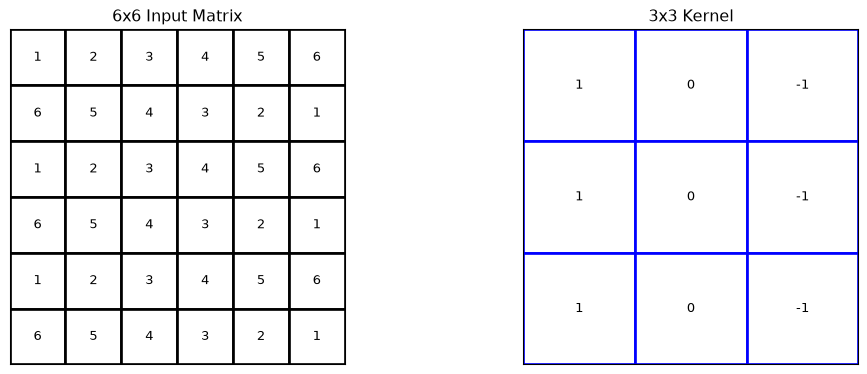

A **kernel** (aka filter) is a small matrix, usually $3 \times 3$,
$5 \times 5$, or similar in size, that **slides over** the input data
(such as an image) to perform **convolution**.

The definition of a **convolution** will be introduced shortly. For now,
consider systematically the ways in which the kernel can overlap the
input matrix.

## Kernel

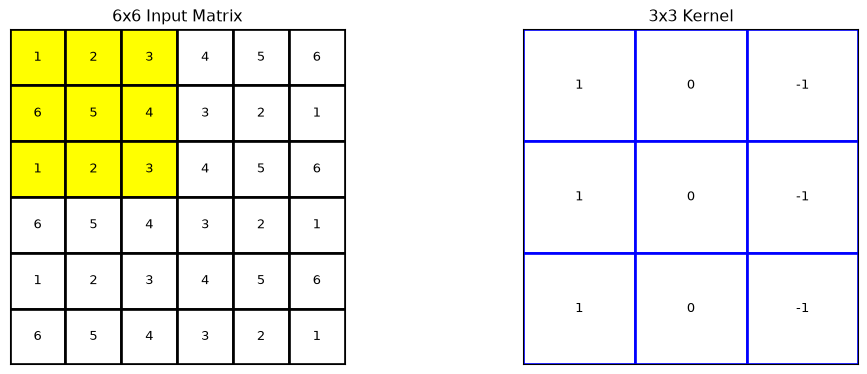

Beginning with the kernel positioned to overlap the upper-left corner of
the input matrix.

The detailed computational process will be elaborated upon subsequently.
At this stage, it is sufficient to observe that the kernel is
systematically traversed across the input matrix, generating a distinct
output with each iteration.

## Kernel

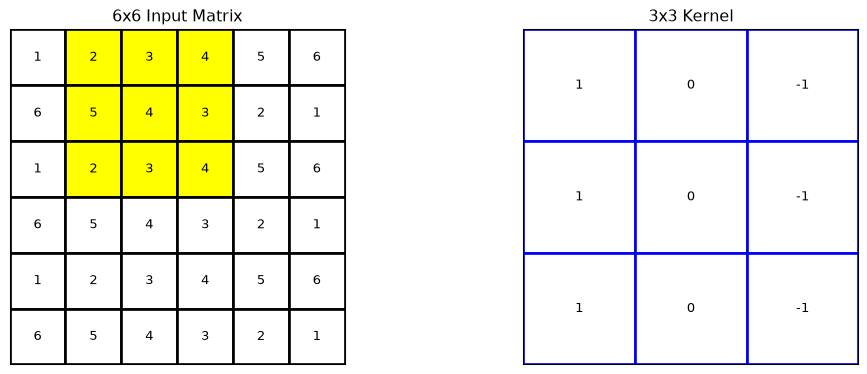

It can be moved to the right three times.

## Kernel

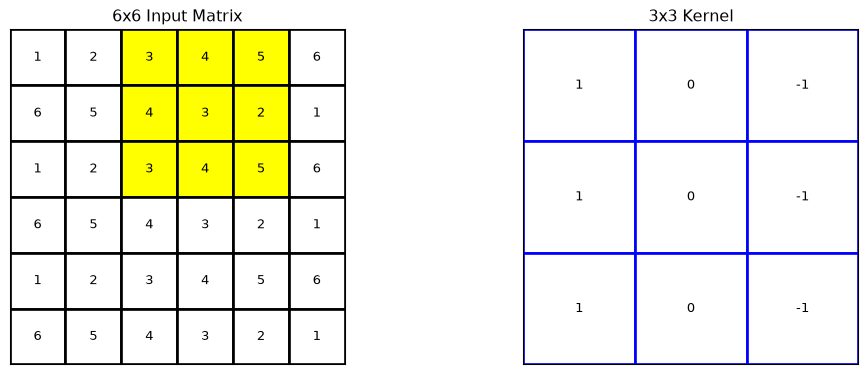

## Kernel

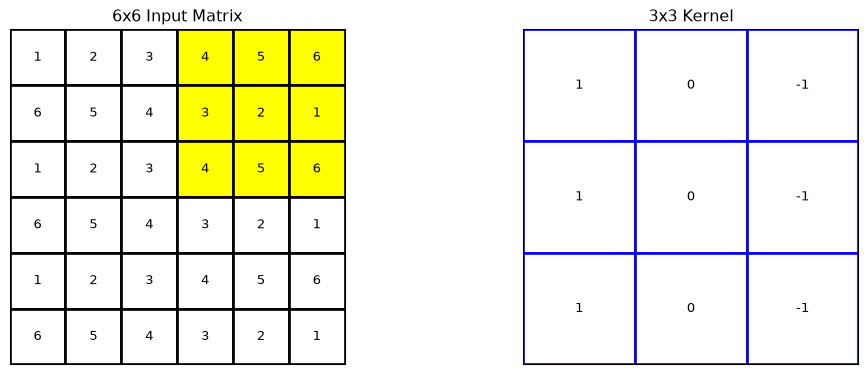

## Kernel

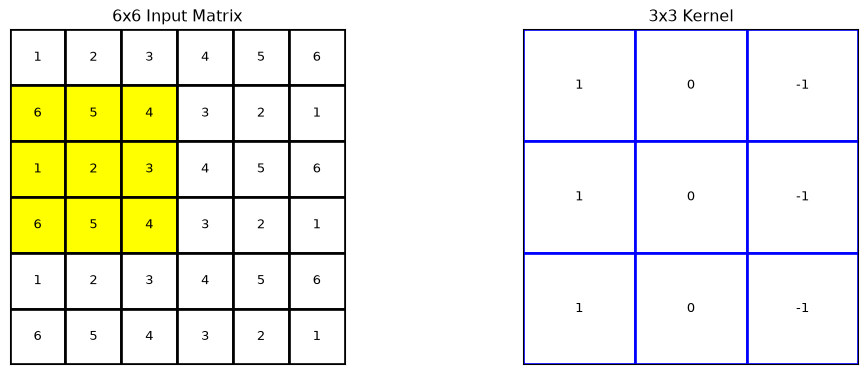

The kernel can then be moved to the second row of the input matrix, and
moved to the right three times.

How many placements of the kernel over the input matrix are there?
$4 \times 4 = 16$.

## Kernel Placements

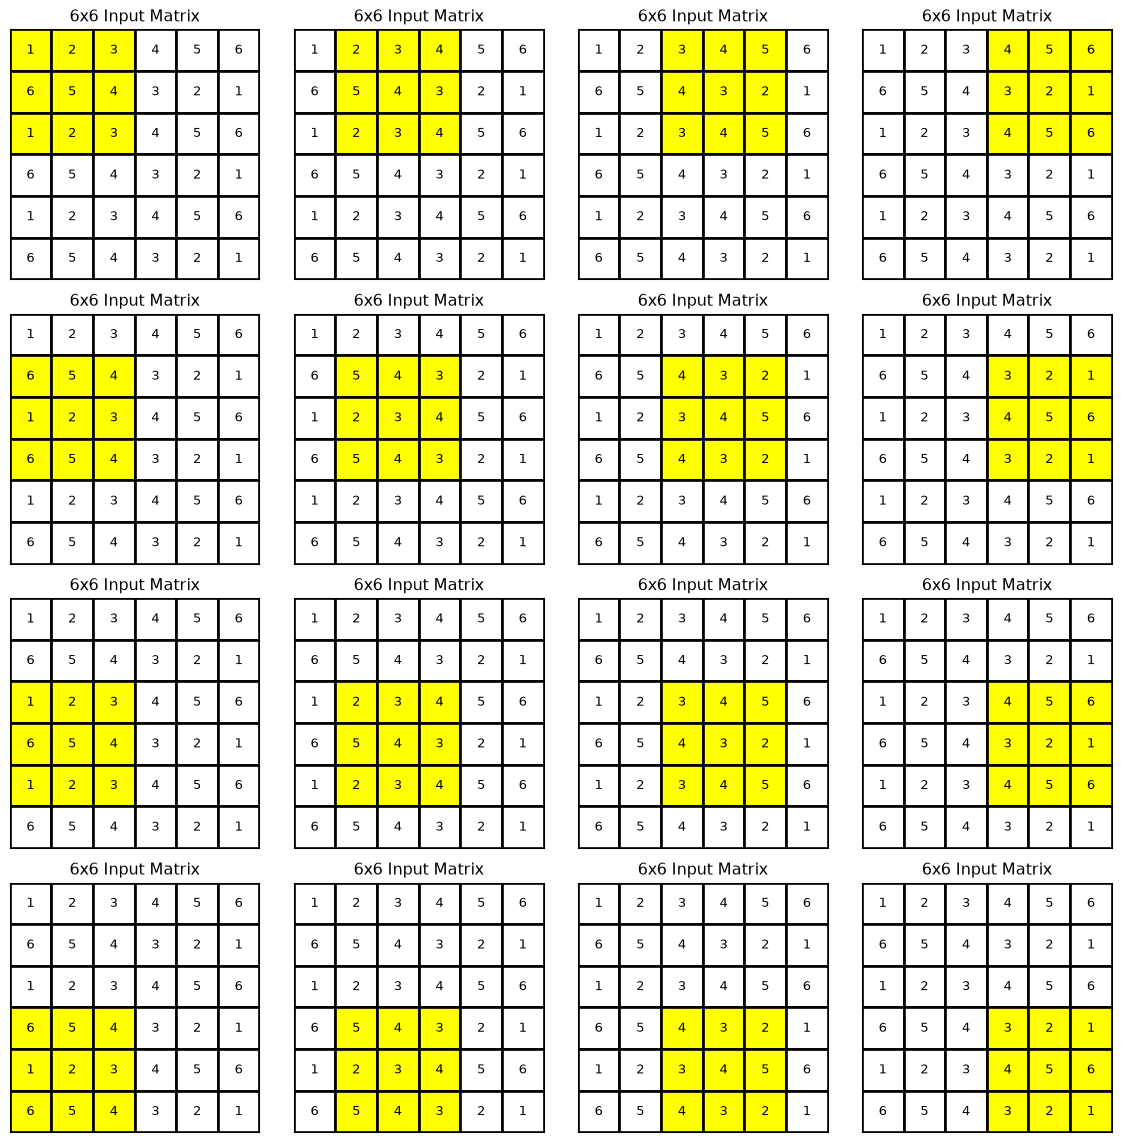

## Kernel

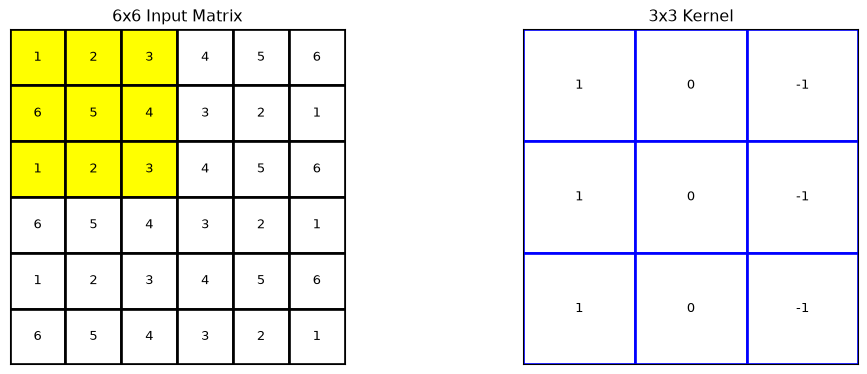

With the kernel placed over a specific region of the input matrix, the
**convolution** is **element-wise multiplication** (each element of the
kernel is multiplied by the corresponding element of the input matrix
region it overlaps) followed by a **summation** of the results to
produce a **single scalar value**.

## Kernel

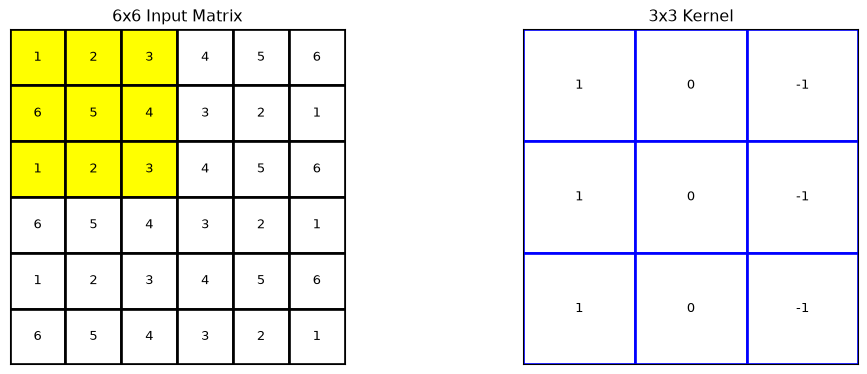

$1 \times 1 + 2 \times 0 + 3 \times (-1) + 6 \times 1 + 5 \times 0 + 4 \times (-1) + 1 \times 1 + 2 \times 0 + 3 \times (-1) = -2$

## Kernel

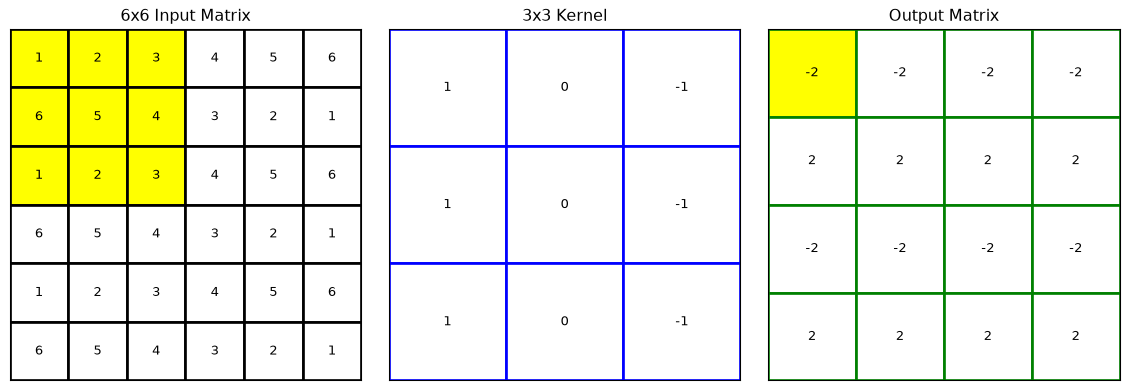

The 16 resulting values can be organized into an **output matrix**. The
element at position (0,0) in this output matrix represents the result of
applying the convolution operation with the kernel at the initial
position on the input matrix. In convolutional neural networks, the
output matrix is referred to as a **feature map**.

It is referred to as a feature map because these outputs serve as
features for the subsequent layer. In CNNs, the term “feature map”
refers to the output of a convolutional layer after applying filters to
the input data. These feature maps capture various patterns or features
from the input, such as edges or textures in image data.

The output feature maps of one layer become the input for the next
layer, effectively serving as features that the subsequent layer can use
to learn more complex patterns. This hierarchical feature extraction
process is a key characteristic of CNNs, allowing them to build
progressively more abstract and high-level representations of the input
data as the network depth increases.

## Classical Image Processing

We now consider **grayscale images** as **input matrices** and examine
two **hand-crafted 2D filters**: Gaussian blurring and Sobel edge
detection.

**No** machine learning is involved.

## Blurring

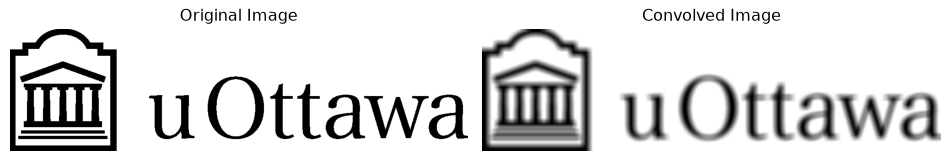

In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def apply_kernel_to_image(image_path, kernel):
    # Load the image and convert it to grayscale
    image = Image.open(image_path).convert('L')
    image_array = np.array(image)

    # Apply the convolution using the provided kernel
    convolved_array = convolve(image_array, kernel, mode='reflect')

    # Convert the convolved array back to an image
    convolved_image = Image.fromarray(convolved_array)

    # Display the original and convolved images
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(image_array, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Convolved Image')
    plt.imshow(convolved_image, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example of a 3x3 averaging kernel

kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

def make_kernel(size):
    return np.full((size, size), 1 / (size ** 2))

kernel = make_kernel(15)

# Apply the kernel to the image (provide your image path here)
image_path = '../../assets/images/uottawa_hor_black.png'
apply_kernel_to_image(image_path, kernel)

In [13]:
# 3x3 averaging kernel

kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

A pixel is transformed into the **average of itself and its eight
surrounding neighbors**, resulting in a blurred effect on the image.

The application of kernels to images has been a longstanding practice in
the field of image processing.

## Vertical Edge Detection

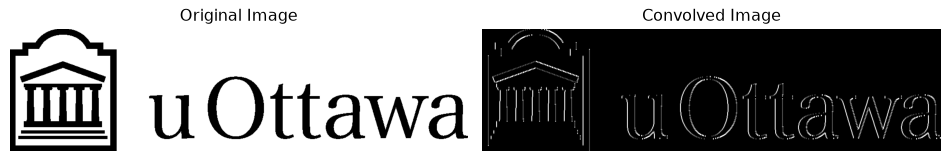

In [15]:
# Define the 3x3 kernel

kernel = np.array([
    [-0.25, 0, 0.25],
    [-0.25, 0, 0.25],
    [-0.25, 0, 0.25]
])

This kernel detects vertical edges by **emphasizing differences in
intensity between adjacent columns**. It subtracts pixel values on the
left from those on the right, enhancing vertical transitions and
suppressing uniform regions.

This is a type of **edge detection kernel**, specifically a horizontal
gradient filter or a Sobel operator. It’s designed to detect changes in
intensity along the horizontal axis, emphasizing vertical edges in an
image.

When this kernel is convolved with an image:

- It highlights vertical edges by calculating the difference in pixel
  intensity between the left and right sides of a point.
- The negative values (-1) on the left subtract intensity, while the
  positive values (1) on the right add intensity, effectively measuring
  the horizontal gradient.
- The zeros in the middle ignore the central pixel’s contribution,
  focusing only on the contrast between left and right neighbors.

The result is an image where:

- Vertical edges (e.g., the boundary between a dark object and a light
  background) appear bright or dark, depending on the direction of the
  intensity change.
- Horizontal edges or uniform areas tend to be suppressed (close to
  zero).

Imagine sliding this kernel over an image like a scanner. For each
pixel:

- It looks at the pixels to its left (subtracting their value with -1)
  and to its right (adding their value with 1).

- If the left and right sides are similar (e.g., same color), the result
  is near zero (no edge).

- If the left is dark and the right is light (or vice versa), the result
  is a strong positive or negative value, showing a vertical edge.

This is useful in computer vision (like in Tesla’s CNNs) to help detect
object boundaries or lane lines by emphasizing where pixel values change
sharply in the horizontal direction.

## Horizontal Edge Detection

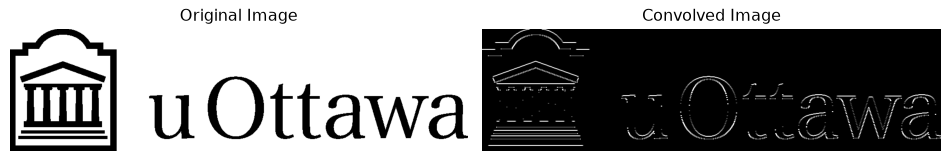

In [17]:
# Define the 3x3 averaging kernel

kernel = np.array([
    [-0.25, -0.25, -0.25],
    [0, 0, 0],
    [0.25, 0.25, 0.25]
])

This kernel detects horizontal edges by **highlighting differences in
intensity between adjacent rows**. It subtracts pixel values in the
upper row from those in the lower row, accentuating horizontal
transitions while minimizing uniform areas.

## Convolutions in Image Processing

<https://www.youtube.com/watch?v=8rrHTtUzyZA>

Uses the **[Julia](https://julialang.org)** programming language.

## But what is a convolution?

<https://youtu.be/KuXjwB4LzSA>

**Convolution** extending beyond its application in image processing.

## Kernels

In contrast to image processing, where kernels are manually defined by
the user, in **convolutional networks**, the **kernels are automatically
learned** by the network.

To be continued $\ldots$

# Conv1D

## Definition

For a 1D input array $x$, a (learned) weight vector
$w \in \mathbb{R}^K$, and a scalar bias $b$, the discrete 1D
cross-correlation (convolution) output $y$ at index $i$ is defined as:

$$
    y[i] = b + \sum_{j=0}^{K-1} w[j] x[i+j] 
$$

Given the above definition, discuss the length of $y$.

**Cross-Correlation vs. True Convolution**

In signal processing, a formal mathematical convolution requires the
kernel to be mirrored (spatially flipped) before the sliding dot product
is computed:

$$
    y_{conv}[i] = \sum_{j=0}^{K-1} x[i+j] w[K-1-j]
$$ Deep learning libraries omit this kernel flip, opting for
cross-correlation. Because the weight values in $w$ are randomly
initialized and learned via gradient descent, the mathematical flip is
redundant; the optimization algorithm simply learns the “pre-flipped”
representation of the optimal filter.

**Mechanics**

- **Alignment:** The weight array $w$ is placed over the first $K$
  elements of the input array $x$.
- **Dot Product:** An element-wise multiplication is performed between
  the aligned values, and the results are summed. The bias $b$ is added
  to this scalar sum.
- **Translation:** The weight array shifts by a designated increment
  (stride) across the input sequence, repeating the dot product at each
  valid position to populate the output array $y$ (the feature map).

## Applications

### Time-Series Analysis and Forecasting

1D CNNs efficiently capture temporal dependencies without the sequential
processing bottleneck of Recurrent Neural Networks (RNNs).

- **Medical Diagnostics:** Classifying anomalies in continuous
  physiological signals, such as Electrocardiogram (ECG) or
  Electroencephalogram (EEG) waveforms.
- **Predictive Maintenance:** Detecting industrial equipment degradation
  by processing high-frequency sensor telemetry (e.g., vibration or
  temperature logs).
- **Financial Modeling:** Forecasting market movements or volatility
  from historical price and volume sequences.
- **Climate Modeling:** Predicting localized weather patterns from
  historical meteorological time-series data.

### Natural Language Processing (NLP)

While Transformers dominate large-scale NLP, 1D CNNs remain highly
efficient for localized, syntax-driven text processing using word or
character embeddings.

- **Document Classification:** Performing sentiment analysis, topic
  categorization, or spam detection by extracting local n-gram features
  (e.g., Yoon Kim’s CNN for sentence classification).
- **Token-Level Tasks:** Executing part-of-speech (POS) tagging and
  named entity recognition (NER) by assessing words within their
  immediate local context.
- **Intent Recognition:** Identifying user intent in conversational AI
  agents where low-latency inference is critical.

### Digital Signal Processing and Audio

Raw audio waveforms or pre-processed spectrogram slices function as 1D
inputs where filters learn to isolate specific frequencies or phonetic
structures.

- **Speech Recognition:** Processing Mel-frequency cepstral coefficients
  (MFCCs) for acoustic modeling and phoneme transcription.
- **Wake-Word Detection:** Operating low-power, low-latency models on
  edge devices to identify specific audio triggers (e.g., “Hey Siri”).
- **Environmental Audio Classification:** Identifying specific ambient
  sounds, such as breaking glass, sirens, or wildlife calls, from raw
  waveform data.
- **Music Analysis:** Classifying genres, extracting BPM, or performing
  automated instrument transcription.

Would you like to detail the tensor dimensions or architectural
specifics for one of these biological sequence problems for your lecture
slides?

### Computational Biology and Bioinformatics

Biological sequences naturally align with 1D convolutions, where the
input length represents the nucleotide or amino acid chain, and the
channels encode the vocabulary.

- **Motif Discovery:** Identifying cell type-specific DNA signatures of
  transcription factor binding by sliding kernels over one-hot encoded
  genomic sequences.
- **Sequence Categorization:** Classifying non-coding RNA sequences
  based on primary structural motifs.
- **Predictive Virology:** Determining RNA virus-host susceptibility by
  extracting localized sequence adaptations.
- **Protein Effector Prediction:** Mapping primary amino acid sequences
  to predict functional properties or structural domains before
  resorting to heavier language models.

# Theory

## What do you see?

(keep with discussion on invariance)

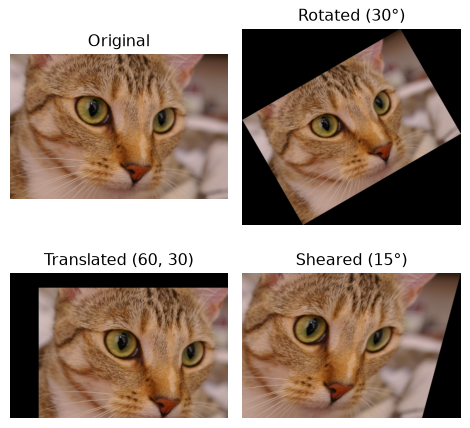

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.util import img_as_float

# Load a sample image (Chelsea the cat)
image = img_as_float(data.chelsea())

# Define transformations
def translate(image, tx=50, ty=30):
    tform = transform.AffineTransform(translation=(tx, ty))
    return transform.warp(image, tform.inverse)

def rotate(image, angle=30):
    return transform.rotate(image, angle, resize=True)

def shear(image, shear_deg=15):
    shear_rad = np.deg2rad(shear_deg)
    tform = transform.AffineTransform(shear=shear_rad)
    return transform.warp(image, tform.inverse)

# Apply transformations
rotated = rotate(image, 30)
translated = translate(image, 60, 30)
sheared = shear(image, 15)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
axes = axes.ravel()
titles = ['Original', 'Rotated (30°)', 'Translated (60, 30)', 'Sheared (15°)']
images = [image, rotated, translated, sheared]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Even though these images look quite different in pixel space, you can
still recognize the cat. A convolutional neural network learns filters
that are robust to these transformations — that’s why it’s so powerful
for vision tasks.

# Prologue

## Summary

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Duis sagittis
posuere ligula sit amet lacinia. Duis dignissim pellentesque magna,
rhoncus congue sapien finibus mollis. Ut eu sem laoreet, vehicula ipsum
in, convallis erat. Vestibulum magna sem, blandit pulvinar augue sit
amet, auctor malesuada sapien. Nullam faucibus leo eget eros hendrerit,
non laoreet ipsum lacinia. Curabitur cursus diam elit, non tempus ante
volutpat a. Quisque hendrerit blandit purus non fringilla. Integer sit
amet elit viverra ante dapibus semper. Vestibulum viverra rutrum enim,
at luctus enim posuere eu. Orci varius natoque penatibus et magnis dis
parturient montes, nascetur ridiculus mus.

## Further Reading

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Duis sagittis
posuere ligula sit amet lacinia. Duis dignissim pellentesque magna,
rhoncus congue sapien finibus mollis. Ut eu sem laoreet, vehicula ipsum
in, convallis erat. Vestibulum magna sem, blandit pulvinar augue sit
amet, auctor malesuada sapien. Nullam faucibus leo eget eros hendrerit,
non laoreet ipsum lacinia. Curabitur cursus diam elit, non tempus ante
volutpat a. Quisque hendrerit blandit purus non fringilla. Integer sit
amet elit viverra ante dapibus semper. Vestibulum viverra rutrum enim,
at luctus enim posuere eu. Orci varius natoque penatibus et magnis dis
parturient montes, nascetur ridiculus mus.

## Resources

- **A guide to convolution arithmetic for deep learning**
- Authors: Vincent Dumoulin and Francesco Visin
- Last revised: 11 Jan 2018
  - [arXiv:1603.07285](https://arxiv.org/abs/1603.07285)
  - [GitHub Repository](https://github.com/vdumoulin/conv_arithmetic/)

## Next lecture

- We will introduce solution spaces.

## References

Géron, Aurélien. 2019. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 2nd ed. O’Reilly Media.

Russell, Stuart, and Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4th ed. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

School of Electrical Engineering and **Computer Science** (EE**CS**)

University of Ottawa